# Model-Free Reinforcement Learning: Monte Carlo and Temporal-Difference Control

## Tutorial Overview (60 minutes)

This tutorial focuses on **control** (finding optimal policies) using Q-functions:
1. **Monte Carlo Control** (15 min)
2. **SARSA (On-Policy TD Control)** (15 min)
3. **Q-Learning (Off-Policy TD Control)** (15 min)
4. **Comparison & Bias-Variance Analysis** (15 min)

### Learning Objectives
- Implement Monte Carlo control methods
- Understand SARSA (on-policy) vs Q-learning (off-policy)
- Compare bootstrapping vs full returns
- Analyze bias-variance tradeoffs empirically

---

## Setup and Dependencies

In [ ]:
# Install required packages
!pip install torch matplotlib numpy tqdm --quiet

In [3]:
# Import necessary libraries
import torch
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from tqdm import tqdm
import random

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

# GPU setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory Available: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

Using device: cpu


## Part 1: GridWorld Environment

We'll use a **5x5 GridWorld** with features that make learning interesting:
- **Walls** (black) at (1,1), (2,3), (3,1) — block movement (agent stays in place)
- **Traps** (orange) at (1,3), (3,2) — give **-5 penalty** each visit
- **Goal** (gold) at (4,4) — gives **+10 reward** and ends the episode
- All other steps cost **-1** (encourages finding short paths)

### Grid (5×5)
```
S . . . .
. # . T .
. . . # .
. # T . .
. . . . G
```

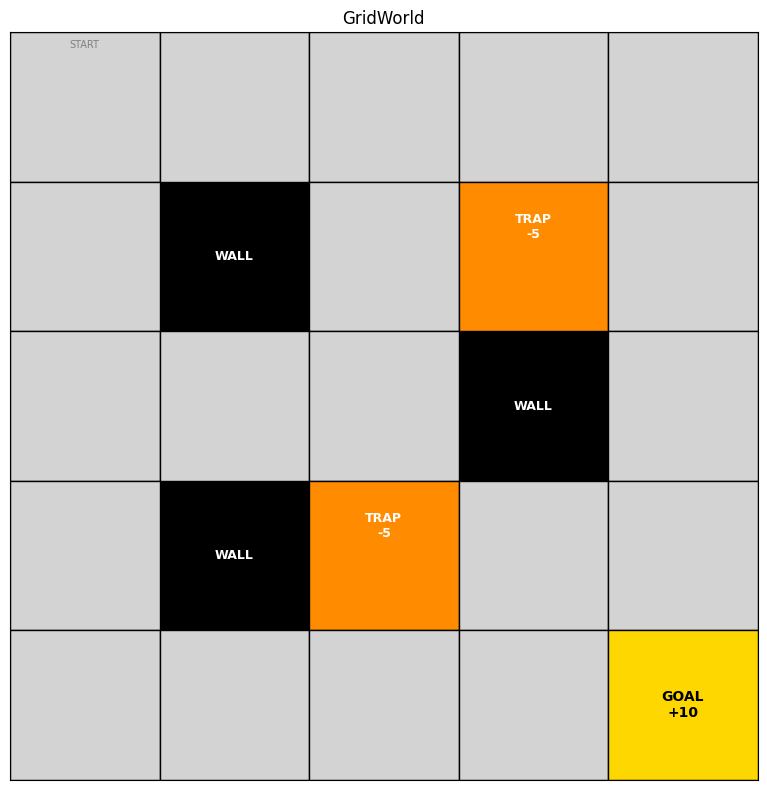

In [4]:
class GridWorld:
    """5x5 GridWorld with walls and traps"""

    def __init__(self, size=5):
        self.size = size
        self.start_state = (0, 0)
        self.goal_state = (size - 1, size - 1)
        self.walls = [(1, 1), (2, 3), (3, 1)]
        self.traps = [(1, 3), (3, 2)]
        self.reset()

    def reset(self):
        self.state = self.start_state
        return self.state

    def step(self, action):
        """Actions: 0=up, 1=right, 2=down, 3=left"""
        x, y = self.state

        if action == 0:  # up
            nx, ny = max(0, x - 1), y
        elif action == 1:  # right
            nx, ny = x, min(self.size - 1, y + 1)
        elif action == 2:  # down
            nx, ny = min(self.size - 1, x + 1), y
        elif action == 3:  # left
            nx, ny = x, max(0, y - 1)

        # Walls block movement — agent stays in place
        if (nx, ny) in self.walls:
            nx, ny = x, y

        self.state = (nx, ny)

        # Reward structure
        if self.state == self.goal_state:
            return self.state, 10.0, True
        elif self.state in self.traps:
            return self.state, -5.0, False
        else:
            return self.state, -1.0, False

    def render(self, Q=None, title="GridWorld"):
        """Visualize the grid and optionally the learned policy"""
        fig, ax = plt.subplots(figsize=(8, 8))
        action_arrows = {0: '^', 1: '>', 2: 'v', 3: '<'}

        for i in range(self.size):
            for j in range(self.size):
                if (i, j) in self.walls:
                    ax.add_patch(plt.Rectangle((j, i), 1, 1, facecolor='black'))
                    ax.text(j + 0.5, i + 0.5, 'WALL', ha='center', va='center',
                            fontsize=9, color='white', weight='bold')
                elif (i, j) == self.goal_state:
                    ax.add_patch(plt.Rectangle((j, i), 1, 1, facecolor='gold', edgecolor='black'))
                    ax.text(j + 0.5, i + 0.5, 'GOAL\n+10', ha='center', va='center',
                            fontsize=10, weight='bold')
                elif (i, j) in self.traps:
                    ax.add_patch(plt.Rectangle((j, i), 1, 1, facecolor='darkorange', edgecolor='black'))
                    ax.text(j + 0.5, i + 0.3, 'TRAP\n-5', ha='center', va='center',
                            fontsize=9, weight='bold', color='white')
                    if Q is not None and (i, j) in Q:
                        q_values = Q[(i, j)]
                        if isinstance(q_values, torch.Tensor):
                            q_values = q_values.cpu().numpy()
                        best_action = np.argmax(q_values)
                        ax.text(j + 0.5, i + 0.7, action_arrows[best_action],
                                ha='center', va='center', fontsize=16, color='white')
                else:
                    ax.add_patch(plt.Rectangle((j, i), 1, 1, facecolor='lightgray', edgecolor='black'))
                    if Q is not None and (i, j) in Q:
                        q_values = Q[(i, j)]
                        if isinstance(q_values, torch.Tensor):
                            q_values = q_values.cpu().numpy()
                        best_action = np.argmax(q_values)
                        best_value = q_values[best_action]
                        ax.text(j + 0.5, i + 0.4, action_arrows[best_action],
                                ha='center', va='center', fontsize=20, color='blue')
                        ax.text(j + 0.5, i + 0.75, f'{best_value:.1f}',
                                ha='center', va='center', fontsize=9, style='italic')

        # Mark start cell
        ax.text(0.5, 0.05, 'START', ha='center', va='top', fontsize=7, color='gray')

        ax.set_xlim(0, self.size)
        ax.set_ylim(0, self.size)
        ax.set_aspect('equal')
        ax.invert_yaxis()
        ax.set_xticks([])
        ax.set_yticks([])
        plt.title(title)
        plt.tight_layout()
        return fig


# Test the environment
env = GridWorld()
env.render()
plt.show()

---
## Part 2: Monte Carlo Control

### Theory

Monte Carlo (MC) control learns Q-values from **complete episodes**:
- **No bootstrapping**: Updates based on actual returns
- **High variance, zero bias**: Uses full trajectory
- **Epsilon-greedy exploration**: Balance exploration vs exploitation

**Key Update Rule:**
$$Q(s, a) \leftarrow Q(s, a) + \alpha [G_t - Q(s, a)]$$

where $G_t = R_{t+1} + \gamma R_{t+2} + \gamma^2 R_{t+3} + \ldots$ is the return.

**Policy**: $\pi(s) = \begin{cases} \arg\max_a Q(s,a) & \text{with prob } 1-\epsilon \\ \text{random} & \text{with prob } \epsilon \end{cases}$

### Exercise 1: Implement Monte Carlo

**Complete the TODOs:**
1. `epsilon_greedy_policy()` - action selection
2. `update()` - first-visit MC Q-value update

In [5]:
class MonteCarloControl:
    """Monte Carlo Control - YOU WILL IMPLEMENT THIS!"""

    def __init__(self, n_actions=4, gamma=0.99, alpha=0.1, epsilon=0.1, use_gpu=True):
        self.n_actions = n_actions
        self.gamma = gamma
        self.alpha = alpha
        self.epsilon = epsilon
        self.device = device if use_gpu else torch.device('cpu')
        self.Q = defaultdict(lambda: torch.zeros(n_actions, device=self.device))

    def epsilon_greedy_policy(self, state):
        """TODO: Implement epsilon-greedy action selection"""
        # Hint: With probability epsilon, choose random action
        #       Otherwise, choose action with highest Q-value
        if np.random.random() < self.epsilon:
            return np.random.randint(0, self.n_actions)
        else:
            return  self.Q[state].argmax().item()

    def greedy_policy(self, state):
        """Greedy action selection (for evaluation)"""
        return self.Q[state].argmax().item()

    def generate_episode(self, env, max_steps=200):
        """Generate complete episode (provided)"""
        episode = []
        state = env.reset()
        for _ in range(max_steps):
            action = self.epsilon_greedy_policy(state)
            next_state, reward, done = env.step(action)
            episode.append((state, action, reward))
            state = next_state
            if done:
                break
        return episode

    def update(self, episode):
        """TODO: Implement first-visit Monte Carlo update"""
        # Hint 1: Calculate returns G backwards through episode
        # Hint 2: For first-visit, track visited (state, action) pairs
        # Hint 3: Update rule: Q(s,a) += alpha * (G - Q(s,a))

        G = 0.0
        visited = set()

        for state, action, reward in reversed(episode):
            G = reward + self.gamma * G

            sa_pair = (state, action)
            if sa_pair not in visited:
                visited.add(sa_pair)
                old_q = self.Q[state][action].item()
                self.Q[state][action] += self.alpha * (G-old_q)


    def train(self, env, num_episodes=1000):
        """Training loop (provided)"""
        episode_rewards = []
        for ep in tqdm(range(num_episodes), desc="MC Training"):
            episode = self.generate_episode(env)
            self.update(episode)
            total_reward = sum([r for _, _, r in episode])
            episode_rewards.append(total_reward)
            self.epsilon = max(0.01, self.epsilon * 0.995)
        return episode_rewards

Training Monte Carlo...


MC Training: 100%|██████████| 5000/5000 [00:01<00:00, 3703.96it/s]


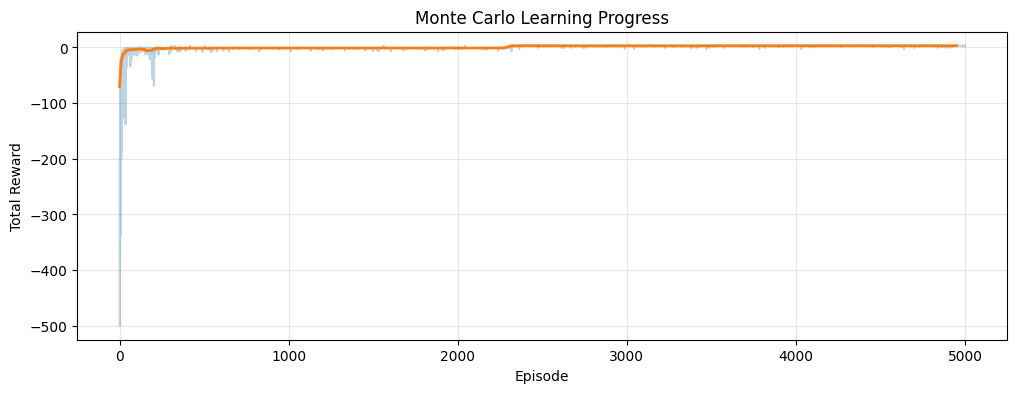

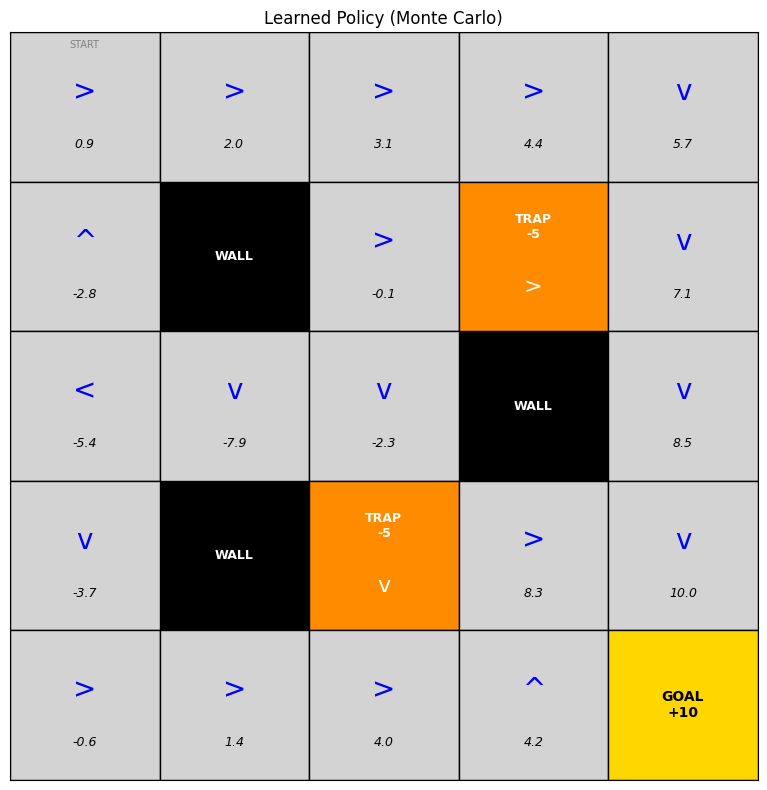

In [6]:
# Train Monte Carlo (needs more episodes than TD methods for the 5x5 grid)
print('Training Monte Carlo...')
env = GridWorld()
mc = MonteCarloControl(gamma=0.95, alpha=0.1, epsilon=0.3)
rewards_mc = mc.train(env, num_episodes=5000)

# Visualize
plt.figure(figsize=(12, 4))
plt.plot(rewards_mc, alpha=0.3)
plt.plot(np.convolve(rewards_mc, np.ones(50) / 50, mode='valid'), linewidth=2)
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.title('Monte Carlo Learning Progress')
plt.grid(True, alpha=0.3)
plt.show()

env.render(Q=mc.Q, title='Learned Policy (Monte Carlo)')
plt.show()

---
## Theory Check 1: Monte Carlo vs TD Learning

**Before continuing, work through these questions (5 minutes)**

### Q1: Monte Carlo - Zero Bias, High Variance

**Explain why Monte Carlo methods have:**
- (a) **Zero bias** (unbiased estimates)
- (b) **High variance**


**Your answer:**
```
(a) Zero bias because:


(b) High variance because:


```

### Q2: Calculate TD Update

Given the following:
- Current Q-value: Q(s,a) = 50
- Reward received: r = 5
- Next state Q-value: Q(s',a') = 8
- Discount factor: gamma = 0.9
- Learning rate: alpha = 0.1

Calculate:
- (a) What is the TD target? - r + gamma x Q(s',a') = 5 + 0,9 * 8 - 12,2
- (b) What is the TD error? - td target - Q(s,a) = 12,2 - 50 = -37,8
- (c) What is the new Q(s,a) after the update? - q(s,a) - alpha x TD error = 50-0,1*-37,8=46,22

**Your answer:**
```
(a) TD target = 
(b) TD error = 
(c) New Q(s,a) = 
```

### Q3: TD Variance

**Why does TD learning have lower variance than Monte Carlo?**

**Your answer:**
```


```

---

---
## Part 3: SARSA (On-Policy TD Control)

### Theory

SARSA (State-Action-Reward-State-Action) is an **on-policy** TD control algorithm:
- Learns Q-values for the policy being followed
- Uses bootstrapping (updates from estimates)
- More conservative than Q-learning

**SARSA Update:**
$$Q(s_t, a_t) \leftarrow Q(s_t, a_t) + \alpha [r_{t+1} + \gamma Q(s_{t+1}, a_{t+1}) - Q(s_t, a_t)]$$

**Key**: Uses actual next action $a_{t+1}$ sampled from policy (e.g., $\epsilon$-greedy).

### Comparison with MC:
- **MC**: Waits for episode end, uses full return G
- **SARSA**: Updates every step, uses one-step lookahead

### Exercise 2: SARSA

**Complete the TODOs:**
1. `epsilon_greedy_policy()` - action selection
2. `update()` - SARSA Q-value update

In [7]:
class SARSA:
    """SARSA: On-policy TD Control - YOU WILL IMPLEMENT THIS!"""

    def __init__(self, n_actions=4, gamma=0.99, alpha=0.1, epsilon=0.1, use_gpu=True):
        self.n_actions = n_actions
        self.gamma = gamma
        self.alpha = alpha
        self.epsilon = epsilon
        self.device = device if use_gpu else torch.device('cpu')
        self.Q = defaultdict(lambda: torch.zeros(n_actions, device=self.device))

    def epsilon_greedy(self, state):
        if np.random.random() < self.epsilon:
            return np.random.randint(0, self.n_actions)
        return self.Q[state].argmax().item()

    def greedy_policy(self, state):
        return self.Q[state].argmax().item()

    def update(self, state, action, reward, next_state, next_action, done):
        """TODO: Implement SARSA update"""
        # Hint: SARSA uses the ACTUAL next action (on-policy)

        current_q = self.Q[state][action]

        if done:
            td_target = reward
        else:
            td_target = reward + self.gamma * self.Q[next_state][next_action]

        td_error = td_target - current_q
        self.Q[state][action] +=self.alpha * td_error

    def train(self, env, num_episodes=1000, max_steps=100):
        """Training loop (provided)"""
        episode_rewards = []
        for ep in tqdm(range(num_episodes), desc="SARSA Training"):
            state = env.reset()
            action = self.epsilon_greedy(state)
            total_reward = 0
            for step in range(max_steps):
                next_state, reward, done = env.step(action)
                next_action = self.epsilon_greedy(next_state)
                self.update(state, action, reward, next_state, next_action, done)
                total_reward += reward
                state, action = next_state, next_action
                if done:
                    break
            episode_rewards.append(total_reward)
            self.epsilon = max(0.01, self.epsilon * 0.995)
        return episode_rewards

Training SARSA...


SARSA Training: 100%|██████████| 3000/3000 [00:01<00:00, 1824.95it/s]


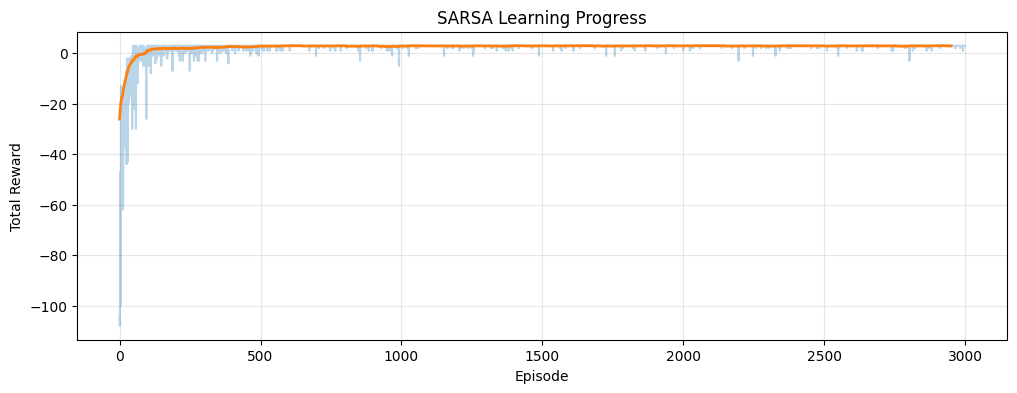

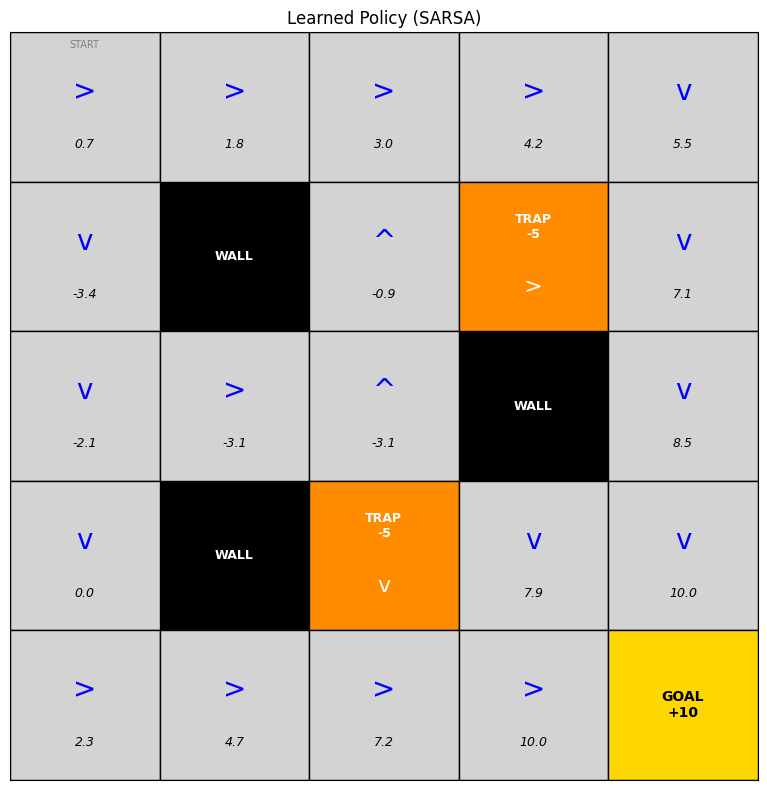

In [8]:
# Train SARSA
print('Training SARSA...')
env = GridWorld()
sarsa = SARSA(gamma=0.95, alpha=0.1, epsilon=0.3)
rewards_sarsa = sarsa.train(env, num_episodes=3000)

plt.figure(figsize=(12, 4))
plt.plot(rewards_sarsa, alpha=0.3)
plt.plot(np.convolve(rewards_sarsa, np.ones(50) / 50, mode='valid'), linewidth=2)
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.title('SARSA Learning Progress')
plt.grid(True, alpha=0.3)
plt.show()

env.render(Q=sarsa.Q, title='Learned Policy (SARSA)')
plt.show()

---
## Part 4: Q-Learning (Off-Policy TD Control)

### Theory

Q-Learning is an **off-policy** TD control algorithm:
- Learns optimal Q-values regardless of behavior policy
- Uses max over next actions (greedy)
- More aggressive than SARSA

**Q-Learning Update:**
$$Q(s_t, a_t) \leftarrow Q(s_t, a_t) + \alpha [r_{t+1} + \gamma \max_a Q(s_{t+1}, a) - Q(s_t, a_t)]$$

**Key difference from SARSA**: Uses $\max_a Q(s_{t+1}, a)$ instead of $Q(s_{t+1}, a_{t+1})$.

This means Q-learning learns the **optimal policy** even while exploring!

### Exercise 3: Q-Learning

**Complete the TODOs:**
1. `epsilon_greedy_policy()` - action selection
2. `update()` - Q-Learning Q-value update

In [12]:
class QLearning:
    """Q-Learning: Off-policy TD Control - YOU WILL IMPLEMENT THIS!"""

    def __init__(self, n_actions=4, gamma=0.99, alpha=0.1, epsilon=0.1, use_gpu=True):
        self.n_actions = n_actions
        self.gamma = gamma
        self.alpha = alpha
        self.epsilon = epsilon
        self.device = device if use_gpu else torch.device('cpu')
        self.Q = defaultdict(lambda: torch.zeros(n_actions, device=self.device))

    def epsilon_greedy(self, state):
        """TODO: Epsilon-greedy"""
        if np.random.random() < self.epsilon:
            return np.random.randint(0, self.n_actions)
        return self.Q[state].argmax().item()

    def greedy_policy(self, state):
        return self.Q[state].argmax().item()

    def update(self, state, action, reward, next_state, done):
        """TODO: Implement Q-Learning update"""
        # Hint: Q-Learning uses MAX over actions (off-policy)

        current_q = self.Q[state][action]

        if done:
            td_target = reward
        else:
            td_target = reward + self.gamma * self.Q[next_state].max()
        td_error = td_target - current_q
        self.Q[state][action] += self.alpha * td_error

    def train(self, env, num_episodes=1000, max_steps=100):
        """Training loop (provided)"""
        episode_rewards = []
        for ep in tqdm(range(num_episodes), desc="Q-Learning Training"):
            state = env.reset()
            total_reward = 0
            for step in range(max_steps):
                action = self.epsilon_greedy(state)
                next_state, reward, done = env.step(action)
                self.update(state, action, reward, next_state, done)
                total_reward += reward
                state = next_state
                if done:
                    break
            episode_rewards.append(total_reward)
            self.epsilon = max(0.01, self.epsilon * 0.995)
        return episode_rewards

Training Q-Learning...


Q-Learning Training: 100%|██████████| 3000/3000 [00:01<00:00, 1868.90it/s]


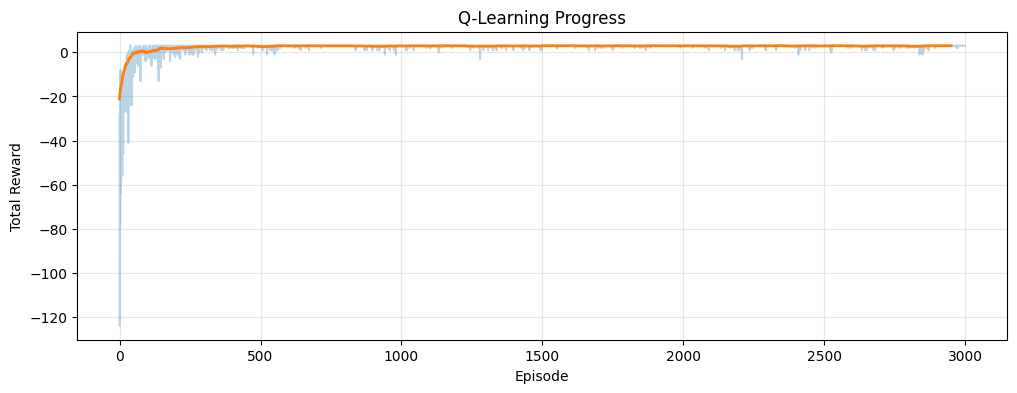

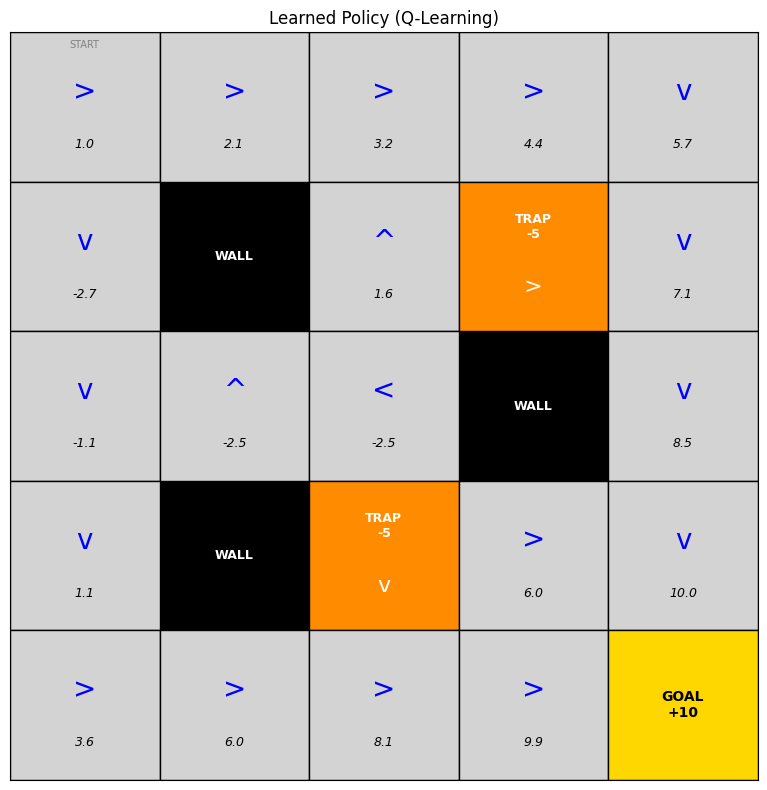

In [13]:
# Train Q-Learning
print('Training Q-Learning...')
env = GridWorld()
qlearning = QLearning(gamma=0.95, alpha=0.1, epsilon=0.3)
rewards_qlearning = qlearning.train(env, num_episodes=3000)

plt.figure(figsize=(12, 4))
plt.plot(rewards_qlearning, alpha=0.3)
plt.plot(np.convolve(rewards_qlearning, np.ones(50) / 50, mode='valid'), linewidth=2)
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.title('Q-Learning Progress')
plt.grid(True, alpha=0.3)
plt.show()

env.render(Q=qlearning.Q, title='Learned Policy (Q-Learning)')
plt.show()

---
## Theory Check 2: On/Off-Policy

**Q3:** Q(s,a1)=10, Q(s,a2)=15. Agent picks a1, gets r=5. gamma=0.9, alpha=0.1

Calculate SARSA and Q-Learning updates. Which is larger?

**Your answer:**
```
SARSA update: 10 + 0,1(5+0,9*10-10)=10,4

Q-Learning update: 10 + 0,1(5+0,9*15-10)=10,85

Which is larger and why?
```

---

---
## Part 5: MC vs SARSA vs Q-Learning Comparison

Let's compare all three algorithms side-by-side:

In [ ]:
# Compare all three
plt.figure(figsize=(14, 5))
window = 50
plt.plot(np.convolve(rewards_mc, np.ones(window) / window, mode='valid'), label='Monte Carlo', linewidth=2)
plt.plot(np.convolve(rewards_sarsa, np.ones(window) / window, mode='valid'), label='SARSA', linewidth=2)
plt.plot(np.convolve(rewards_qlearning, np.ones(window) / window, mode='valid'), label='Q-Learning', linewidth=2)
plt.xlabel('Episode')
plt.ylabel('Average Reward')
plt.title('Comparison: MC vs SARSA vs Q-Learning')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Summary statistics
print("\n" + "=" * 70)
print("FINAL PERFORMANCE COMPARISON (Last 100 Episodes)")
print("=" * 70)
print(f"{'Method':<20} {'Avg Reward':>12}")
print("-" * 35)
print(f"{'Monte Carlo':<20} {np.mean(rewards_mc[-100:]):>12.2f}")
print(f"{'SARSA':<20} {np.mean(rewards_sarsa[-100:]):>12.2f}")
print(f"{'Q-Learning':<20} {np.mean(rewards_qlearning[-100:]):>12.2f}")
print("=" * 35)

print("\nKEY INSIGHTS:")
print("- TD methods (SARSA, Q-Learning) converge faster than MC")
print("- Q-Learning often fastest (learns optimal policy off-policy)")
print("- All three find optimal policy eventually")
print("- Bootstrapping (TD) trades bias for lower variance")

---
## Part 6: SARSA vs Q-Learning on Cliff Walking

The classic **Cliff Walking** problem (Sutton & Barto, Example 6.6) demonstrates the key difference between on-policy (SARSA) and off-policy (Q-Learning).

**Layout**: 4x10 grid. Start = bottom-left, Goal = bottom-right, Cliff = entire bottom row between them.
- Stepping on the cliff gives **-100** reward and resets to start
- The **optimal path** walks right along the cliff edge (shortest)
- The **safe path** goes up and across the top (longer but no cliff risk)

**Key insight**: Q-Learning learns the optimal (risky) path. SARSA learns the safe path because it accounts for the fact that epsilon-greedy exploration can randomly step into the cliff.

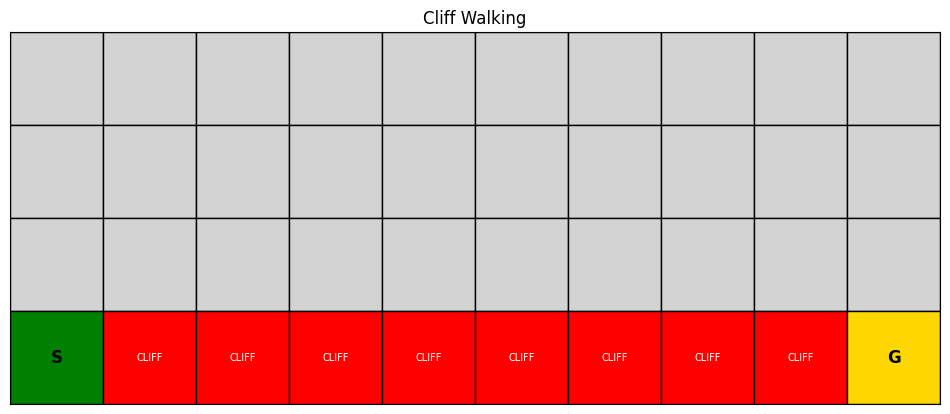

Cliff Walking Training: 100%|██████████| 500/500 [00:01<00:00, 411.23it/s]


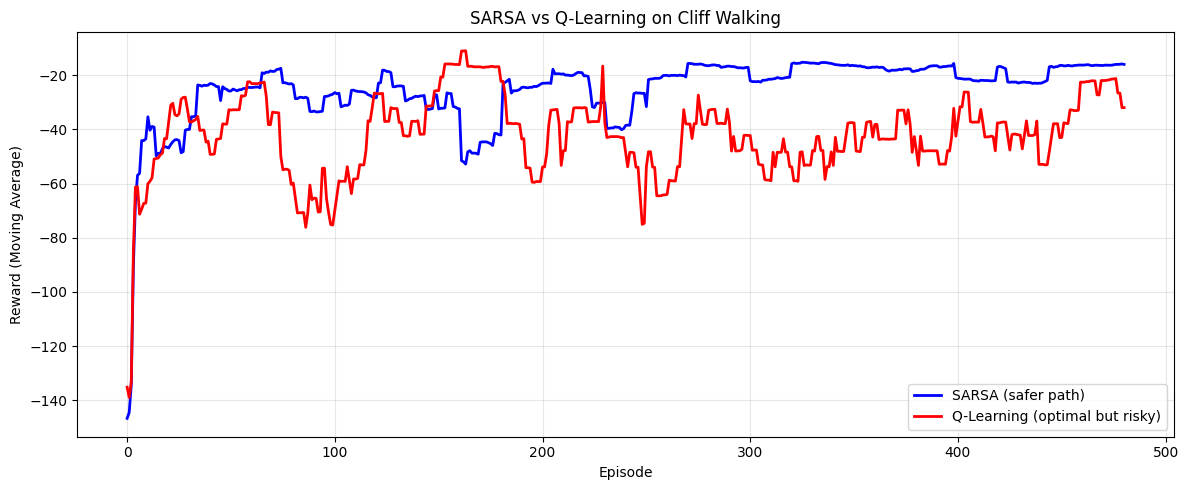

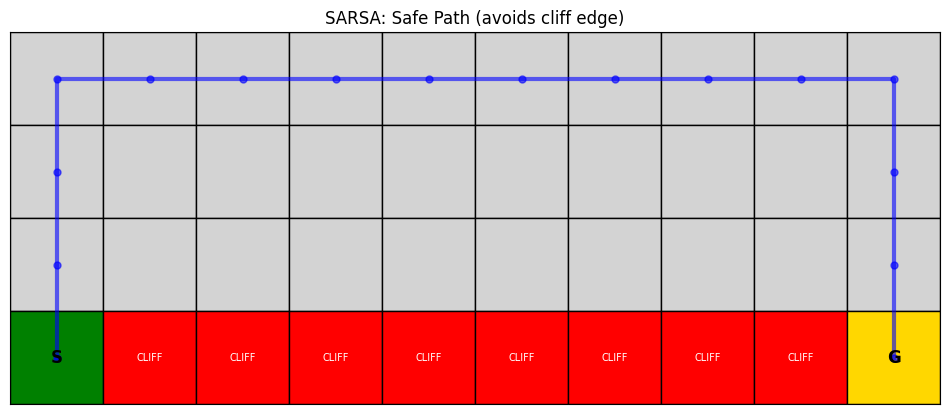

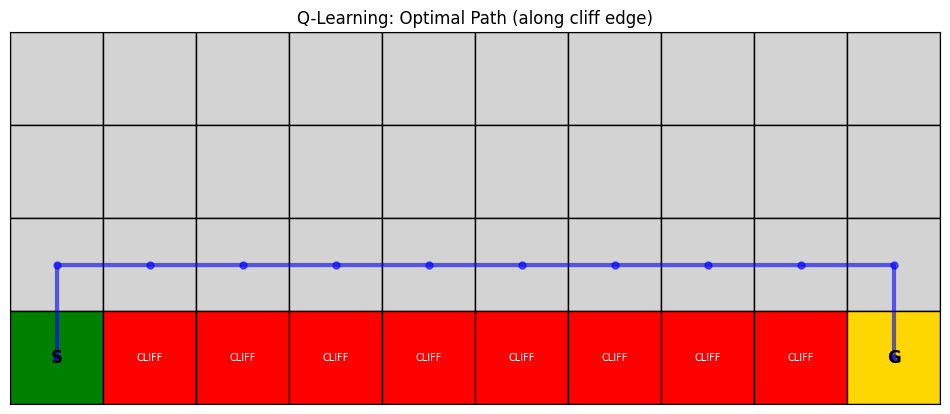


KEY DIFFERENCE: On-Policy (SARSA) vs Off-Policy (Q-Learning)
SARSA (On-Policy):
  - Learns value of policy being followed (epsilon-greedy)
  - Takes SAFER path away from cliff edge
  - Higher average reward during training (fewer cliff falls)

Q-Learning (Off-Policy):
  - Learns optimal policy regardless of behavior
  - Takes OPTIMAL path right along cliff edge
  - Lower average reward during training (cliff falls from exploration)


In [15]:
class CliffWalking:
    """Classic Cliff Walking (Sutton & Barto Example 6.6)
    4x10 grid. Start=bottom-left, Goal=bottom-right.
    Cliff along the bottom row between start and goal."""

    def __init__(self):
        self.rows = 4
        self.cols = 10
        self.start = (3, 0)
        self.goal = (3, 9)
        # Cliff: bottom row columns 1-8
        self.cliff = [(3, c) for c in range(1, 9)]
        self.reset()

    def reset(self):
        self.state = self.start
        return self.state

    def step(self, action):
        """Actions: 0=up, 1=right, 2=down, 3=left"""
        x, y = self.state

        if action == 0:
            x = max(0, x - 1)
        elif action == 1:
            y = min(self.cols - 1, y + 1)
        elif action == 2:
            x = min(self.rows - 1, x + 1)
        elif action == 3:
            y = max(0, y - 1)

        self.state = (x, y)

        if self.state in self.cliff:
            self.state = self.start
            return self.state, -100, False
        elif self.state == self.goal:
            return self.state, 0, True
        else:
            return self.state, -1, False

    def render(self, path=None, title="Cliff Walking"):
        """Visualize the cliff environment"""
        fig, ax = plt.subplots(figsize=(12, 5))

        for i in range(self.rows):
            for j in range(self.cols):
                if (i, j) == self.start:
                    ax.add_patch(plt.Rectangle((j, i), 1, 1, facecolor='green', edgecolor='black'))
                    ax.text(j + 0.5, i + 0.5, 'S', ha='center', va='center', fontsize=12, weight='bold')
                elif (i, j) == self.goal:
                    ax.add_patch(plt.Rectangle((j, i), 1, 1, facecolor='gold', edgecolor='black'))
                    ax.text(j + 0.5, i + 0.5, 'G', ha='center', va='center', fontsize=12, weight='bold')
                elif (i, j) in self.cliff:
                    ax.add_patch(plt.Rectangle((j, i), 1, 1, facecolor='red', edgecolor='black'))
                    ax.text(j + 0.5, i + 0.5, 'CLIFF', ha='center', va='center', fontsize=7, color='white')
                else:
                    ax.add_patch(plt.Rectangle((j, i), 1, 1, facecolor='lightgray', edgecolor='black'))

        if path:
            path_x = [p[1] + 0.5 for p in path]
            path_y = [p[0] + 0.5 for p in path]
            ax.plot(path_x, path_y, 'b-', linewidth=3, alpha=0.6, marker='o', markersize=5)

        ax.set_xlim(0, self.cols)
        ax.set_ylim(0, self.rows)
        ax.set_aspect('equal')
        ax.invert_yaxis()
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_title(title)
        return fig


# Visualize the environment
cliff_env = CliffWalking()
cliff_env.render()
plt.show()

# Train with fixed epsilon to get comparable reward curves
# Fixed epsilon is critical: the SARSA vs Q-Learning difference only shows
# when the agent keeps exploring (epsilon > 0) throughout training.
sarsa_cliff = SARSA(gamma=0.99, alpha=0.5, epsilon=0.1)
ql_cliff = QLearning(gamma=0.99, alpha=0.5, epsilon=0.1)

rewards_sarsa_cliff = []
rewards_ql_cliff = []
for ep in tqdm(range(500), desc="Cliff Walking Training"):
    # SARSA episode
    env = CliffWalking()
    state = env.reset()
    action = sarsa_cliff.epsilon_greedy(state)
    total_r = 0
    for _ in range(200):
        ns, r, done = env.step(action)
        na = sarsa_cliff.epsilon_greedy(ns)
        sarsa_cliff.update(state, action, r, ns, na, done)
        total_r += r
        state, action = ns, na
        if done: break
    rewards_sarsa_cliff.append(total_r)
    sarsa_cliff.epsilon = 0.1  # keep fixed

    # Q-Learning episode
    env = CliffWalking()
    state = env.reset()
    total_r = 0
    for _ in range(200):
        action = ql_cliff.epsilon_greedy(state)
        ns, r, done = env.step(action)
        ql_cliff.update(state, action, r, ns, done)
        total_r += r
        state = ns
        if done: break
    rewards_ql_cliff.append(total_r)
    ql_cliff.epsilon = 0.1  # keep fixed

# Compare performance
plt.figure(figsize=(12, 5))
window = 20
plt.plot(np.convolve(rewards_sarsa_cliff, np.ones(window) / window, mode='valid'),
         label='SARSA (safer path)', linewidth=2, color='blue')
plt.plot(np.convolve(rewards_ql_cliff, np.ones(window) / window, mode='valid'),
         label='Q-Learning (optimal but risky)', linewidth=2, color='red')
plt.xlabel('Episode')
plt.ylabel('Reward (Moving Average)')
plt.title('SARSA vs Q-Learning on Cliff Walking')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# Show learned paths (greedy, no exploration)
def get_path(agent, env, max_steps=50):
    """Extract greedy path from learned policy"""
    path = []
    state = env.reset()
    path.append(state)
    for _ in range(max_steps):
        action = agent.greedy_policy(state)
        state, _, done = env.step(action)
        path.append(state)
        if done:
            break
    return path


sarsa_path = get_path(sarsa_cliff, CliffWalking())
CliffWalking().render(path=sarsa_path, title='SARSA: Safe Path (avoids cliff edge)')
plt.show()

ql_path = get_path(ql_cliff, CliffWalking())
CliffWalking().render(path=ql_path, title='Q-Learning: Optimal Path (along cliff edge)')
plt.show()

print("\n" + "=" * 70)
print("KEY DIFFERENCE: On-Policy (SARSA) vs Off-Policy (Q-Learning)")
print("=" * 70)
print("SARSA (On-Policy):")
print("  - Learns value of policy being followed (epsilon-greedy)")
print("  - Takes SAFER path away from cliff edge")
print("  - Higher average reward during training (fewer cliff falls)")
print("")
print("Q-Learning (Off-Policy):")
print("  - Learns optimal policy regardless of behavior")
print("  - Takes OPTIMAL path right along cliff edge")
print("  - Lower average reward during training (cliff falls from exploration)")
print("=" * 70)

---
### Part 6 Follow-up

Answer the following theoretical questions



**Q4:** Robot in warehouse with expensive equipment - SARSA or Q-Learning? Why?

**Your answer:**
```

```

**Q5:** Cliff Walking - why does SARSA take safer path?

**Your answer:**
```

```


**Q6 (Math):** Let the return samples for a fixed $(s,a)$ under policy $\pi$ be $G_1,\dots,G_n$ with
$\mathbb{E}[G_i]=q_\pi(s,a)$ and $\mathrm{Var}(G_i)=\sigma^2<\infty$.
Define
$$\hat q_n(s,a)=\frac{1}{n}\sum_{i=1}^n G_i.$$
Show:
1. $\mathbb{E}[\hat q_n(s,a)] = q_\pi(s,a)$
2. $\mathrm{Var}(\hat q_n(s,a)) = \sigma^2/n$
3. Use Chebyshev's inequality to conclude $\hat q_n(s,a) \xrightarrow{P} q_\pi(s,a)$ as $n\to\infty$.

**Your answer:**
```

```



**Q7 (Math - Q-Learning Convergence):** For tabular Q-learning,
$$Q_{t+1}(s_t,a_t)=Q_t(s_t,a_t)+\alpha_t\big[r_t+\gamma\max_{a'}Q_t(s_{t+1},a')-Q_t(s_t,a_t)\big],\quad 0\le\gamma<1.$$

(a) Prove in detail that the Bellman optimality operator
$$ (T^*Q)(s,a)=\mathbb{E}[r+\gamma\max_{a'}Q(s',a')\mid s,a] $$
is a $\gamma$-contraction in sup norm.


**Your answer:**
```

```


---
## Part 7: Bias-Variance Analysis

Let's empirically analyze the bias-variance tradeoff between MC and TD methods.

Computing ground-truth Q-value (long Q-Learning run)...


Q-Learning Training: 100%|██████████| 50000/50000 [00:24<00:00, 2020.73it/s]


Ground-truth Q((1, 2), 1) ≈ -2.1103

Running 25 independent trials (2000 episodes each)...


MC Training: 100%|██████████| 2000/2000 [00:00<00:00, 3778.47it/s]

MC Training: 100%|██████████| 2000/2000 [00:00<00:00, 3513.25it/s]

MC Training: 100%|██████████| 2000/2000 [00:00<00:00, 3890.76it/s]

MC Training: 100%|██████████| 2000/2000 [00:00<00:00, 3830.00it/s]

MC Training: 100%|██████████| 2000/2000 [00:00<00:00, 3121.73it/s]

MC Training: 100%|██████████| 2000/2000 [00:00<00:00, 3645.11it/s]

MC Training: 100%|██████████| 2000/2000 [00:00<00:00, 3911.94it/s]

MC Training: 100%|██████████| 2000/2000 [00:00<00:00, 3344.71it/s]

MC Training: 100%|██████████| 2000/2000 [00:01<00:00, 1079.92it/s][A

MC Training: 100%|██████████| 2000/2000 [00:02<00:00, 731.88it/s]

MC Training: 100%|██████████| 2000/2000 [00:00<00:00, 3465.89it/s]

MC Training: 100%|██████████| 2000/2000 [00:01<00:00, 1641.12it/s]

MC Training: 100%|██████████| 2000/2000 [00:02<00:00, 706.15it/s]

MC Training: 100%|██████████| 2000/2000 [00:00<00:00, 2677.34it/s]

MC Training: 100%|██████████| 2000/2000 [00:00<0

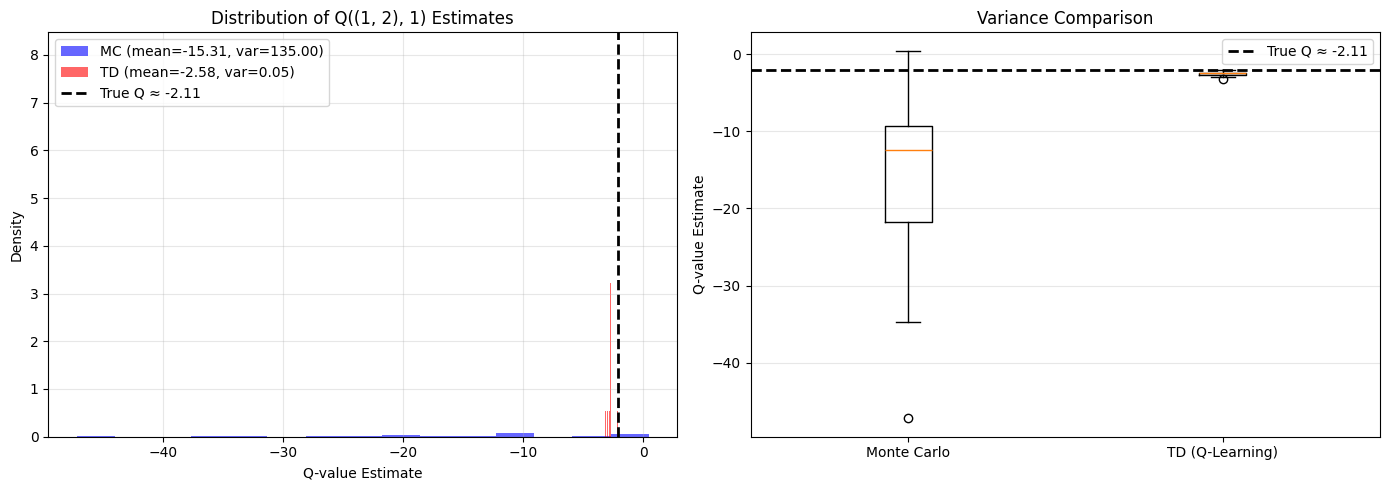


BIAS-VARIANCE ANALYSIS RESULTS

Ground-truth Q-value: -2.1103

Monte Carlo:
  Mean estimate: -15.3074
  Bias:          -13.1971  (mean - true)
  Variance:      135.0032

TD (Q-Learning):
  Mean estimate: -2.5757
  Bias:          -0.4654  (mean - true)
  Variance:      0.0512

KEY INSIGHTS:
  1. MC is theoretically unbiased — with enough episodes its mean
     converges to the true value (dashed line). Its HIGH VARIANCE
     means individual runs scatter widely.
  2. TD has some theoretical bias (bootstrapping), but its LOW
     VARIANCE means estimates cluster tightly together.
  3. PRACTICAL TAKEAWAY: TD's faster convergence often matters
     more than MC's zero-bias guarantee. This is why TD methods
     are preferred in practice.


In [16]:
def compare_mc_td_variance(n_runs=25, n_episodes=2000):
    """Compare variance of MC vs TD Q-value estimates"""

    target_state_action = ((1, 2), 1)
    state, action = target_state_action

    # Estimate the "true" Q-value by running Q-Learning for a very
    # long time with a small learning rate so it converges.
    print("Computing ground-truth Q-value (long Q-Learning run)...")
    true_agent = QLearning(gamma=0.95, alpha=0.05, epsilon=0.1)
    true_agent.train(GridWorld(), num_episodes=50000)
    true_q = true_agent.Q[state][action].item()
    print(f"Ground-truth Q{target_state_action} ≈ {true_q:.4f}\n")

    mc_estimates = []
    td_estimates = []

    print(f"Running {n_runs} independent trials ({n_episodes} episodes each)...")
    for run in tqdm(range(n_runs)):
        mc = MonteCarloControl(gamma=0.95, alpha=0.1, epsilon=0.1)
        mc.train(GridWorld(), num_episodes=n_episodes)
        mc_estimates.append(mc.Q[state][action].item())

        td = QLearning(gamma=0.95, alpha=0.1, epsilon=0.1)
        td.train(GridWorld(), num_episodes=n_episodes)
        td_estimates.append(td.Q[state][action].item())

    mc_estimates = np.array(mc_estimates)
    td_estimates = np.array(td_estimates)

    mc_mean, mc_var = mc_estimates.mean(), mc_estimates.var()
    td_mean, td_var = td_estimates.mean(), td_estimates.var()
    mc_bias = mc_mean - true_q
    td_bias = td_mean - true_q

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].hist(mc_estimates, bins=15, alpha=0.6,
                 label=f'MC (mean={mc_mean:.2f}, var={mc_var:.2f})', density=True, color='blue')
    axes[0].hist(td_estimates, bins=15, alpha=0.6,
                 label=f'TD (mean={td_mean:.2f}, var={td_var:.2f})', density=True, color='red')
    axes[0].axvline(true_q, color='black', linestyle='--', linewidth=2, label=f'True Q ≈ {true_q:.2f}')
    axes[0].set_xlabel('Q-value Estimate')
    axes[0].set_ylabel('Density')
    axes[0].set_title(f'Distribution of Q{target_state_action} Estimates')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].boxplot([mc_estimates, td_estimates], labels=['Monte Carlo', 'TD (Q-Learning)'])
    axes[1].axhline(true_q, color='black', linestyle='--', linewidth=2, label=f'True Q ≈ {true_q:.2f}')
    axes[1].set_ylabel('Q-value Estimate')
    axes[1].set_title('Variance Comparison')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.show()

    print("\n" + "=" * 70)
    print("BIAS-VARIANCE ANALYSIS RESULTS")
    print("=" * 70)
    print(f"\nGround-truth Q-value: {true_q:.4f}")
    print(f"\nMonte Carlo:")
    print(f"  Mean estimate: {mc_mean:.4f}")
    print(f"  Bias:          {mc_bias:.4f}  (mean - true)")
    print(f"  Variance:      {mc_var:.4f}")
    print(f"\nTD (Q-Learning):")
    print(f"  Mean estimate: {td_mean:.4f}")
    print(f"  Bias:          {td_bias:.4f}  (mean - true)")
    print(f"  Variance:      {td_var:.4f}")
    print(f"\nKEY INSIGHTS:")
    print(f"  1. MC is theoretically unbiased — with enough episodes its mean")
    print(f"     converges to the true value (dashed line). Its HIGH VARIANCE")
    print(f"     means individual runs scatter widely.")
    print(f"  2. TD has some theoretical bias (bootstrapping), but its LOW")
    print(f"     VARIANCE means estimates cluster tightly together.")
    print(f"  3. PRACTICAL TAKEAWAY: TD's faster convergence often matters")
    print(f"     more than MC's zero-bias guarantee. This is why TD methods")
    print(f"     are preferred in practice.")
    print("=" * 70)


compare_mc_td_variance()

---
## Summary & Key Takeaways

### Comparison Table

| Method | Bootstrapping | Updates | Bias | Variance | Policy Type | Best For |
|--------|---------------|---------|------|----------|-------------|----------|
| **Monte Carlo** | No | End of episode | Zero | High | Any | Episodic tasks |
| **SARSA** | Yes | Every step | Some | Low | On-policy | Safe exploration |
| **Q-Learning** | Yes | Every step | Some | Low | Off-policy | Finding optimal |

### When to Use Each Method?

**Monte Carlo:**
- Episodic problems only
- When unbiased estimates are critical
- Simple to implement

**SARSA (On-Policy):**
- Safety-critical applications
- Online learning scenarios
- When exploration risk matters
- Takes safer paths

**Q-Learning (Off-Policy):**
- Finding optimal policy
- Offline learning acceptable
- Can tolerate risky exploration
- Most popular in practice

### Key Insights:

1. **Bootstrapping Tradeoff**: TD methods trade bias for lower variance
2. **Convergence**: TD typically converges faster than MC
3. **On vs Off-Policy**: SARSA = safe, Q-Learning = optimal
4. **Q-functions for Control**: More practical than V-functions when model unknown

---

## References

- Sutton & Barto (2018): "Reinforcement Learning: An Introduction" Ch. 5-6
- Watkins & Dayan (1992): "Q-Learning"

---

**Happy Learning!**